<a href="https://colab.research.google.com/github/mTg-creator/Dif_Equations/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_%D0%BF%D1%80%D0%BE_%D1%80%D0%B5%D1%87%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sympy==1.12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


*У меня почему-то sp.dsolve в google Colab не работала на стандартной версии, а в той, которая у меня в PyCharm всё сработало*

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

Импорт нужных библиотек

In [4]:
x = sp.symbols('x')
k = sp.symbols('k')
y = sp.Function('y')

Объявление переменных

In [5]:
ode = sp.Eq(y(x).diff(x), y(x)/ x - k*sp.sqrt(x**2 + y(x)**2)/x )

Получившееся у меня уравнение

In [6]:
sp.pprint(ode)

                  ____________       
                 ╱  2    2           
d            k⋅╲╱  x  + y (x)    y(x)
──(y(x)) = - ───────────────── + ────
dx                   x            x  


In [7]:
res = sp.dsolve(ode, y(x))
print("Общее решение:")
sp.pprint(res)

Общее решение:
             ⎛          ⎛ k⎞⎞
y(x) = x⋅sinh⎝C₁⋅k - log⎝x ⎠⎠


In [12]:
x, x0, y0, k, C1 = sp.symbols('x x0 y0 k C1')
y_new = x * sp.sinh(C1*k - sp.log(x**k))
eq = sp.Eq(y_new.subs(x, x0), y0)
print("Уравнение для C1:")
sp.pprint(eq)

Уравнение для C1:
       ⎛          ⎛  k⎞⎞     
x₀⋅sinh⎝C₁⋅k - log⎝x₀ ⎠⎠ = y₀


Находим С1 из начального условия

In [30]:
C1_solution = sp.solve(eq, C1)
sp.pprint(C1_solution)

⎡   ⎛⎛        ___________⎞           ⎞     ⎛⎛        ___________⎞           ⎞⎤
⎢   ⎜⎜       ╱   2     2 ⎟  k⋅log(x₀)⎟     ⎜⎜       ╱   2     2 ⎟  k⋅log(x₀)⎟⎥
⎢   ⎜⎝y₀ - ╲╱  x₀  + y₀  ⎠⋅ℯ         ⎟     ⎜⎝y₀ + ╲╱  x₀  + y₀  ⎠⋅ℯ         ⎟⎥
⎢log⎜────────────────────────────────⎟  log⎜────────────────────────────────⎟⎥
⎢   ⎝               x₀               ⎠     ⎝               x₀               ⎠⎥
⎢─────────────────────────────────────, ─────────────────────────────────────⎥
⎣                  k                                      k                  ⎦


In [25]:
C1_val = C1_solution[0]

y_final = y_new.subs(C1, C1_val)
y_final = sp.simplify(y_final)
sp.pprint(y_final)

       ⎛             ⎛⎛        ___________⎞           ⎞⎞
       ⎜             ⎜⎜       ╱   2     2 ⎟  k⋅log(x₀)⎟⎟
       ⎜   ⎛ k⎞      ⎜⎝y₀ - ╲╱  x₀  + y₀  ⎠⋅ℯ         ⎟⎟
-x⋅sinh⎜log⎝x ⎠ - log⎜────────────────────────────────⎟⎟
       ⎝             ⎝               x₀               ⎠⎠


Итоговое решение

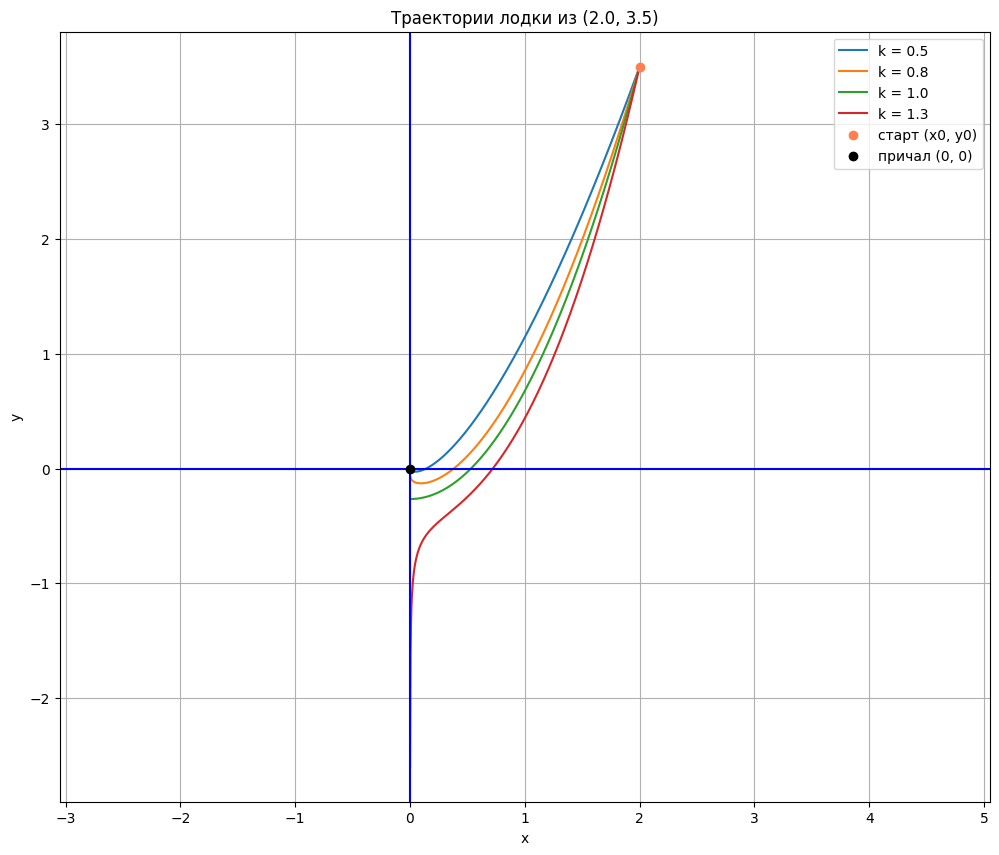

In [41]:
X0 = 2.0
Y0 = 3.5
K_LIST = [0.5, 0.8, 1.0, 1.3]
xs = np.linspace(0.001, X0, 500)
plt.figure(figsize=(12,10))
for kval in K_LIST:
    f = sp.lambdify(x, y_final.subs({x0: X0, y0: Y0, k: kval}), 'numpy')
    plt.plot(xs, f(xs), label=f'k = {kval}')
plt.scatter([X0], [Y0], color='coral', zorder=5, label='старт (x0, y0)')
plt.scatter(0, 0, color='black', zorder=5, label='причал (0, 0)')
plt.axvline(0, color='blue', lw=1.5)
plt.axhline(0, color='blue', lw=1.5)
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Траектории лодки из ({X0}, {Y0})')
plt.legend(); plt.grid(True)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.show()